In [ ]:
# Setup imports and paths
import sys
sys.path.append('../..')  # Add project root to path
import os
os.chdir('../..')  # Change to project root directory
print(f"Working directory: {os.getcwd()}")


# Defect Analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## Overview

In [2]:
ddf = pd.read_csv('defect/2024_defect.csv')
len(ddf['id'])

6704

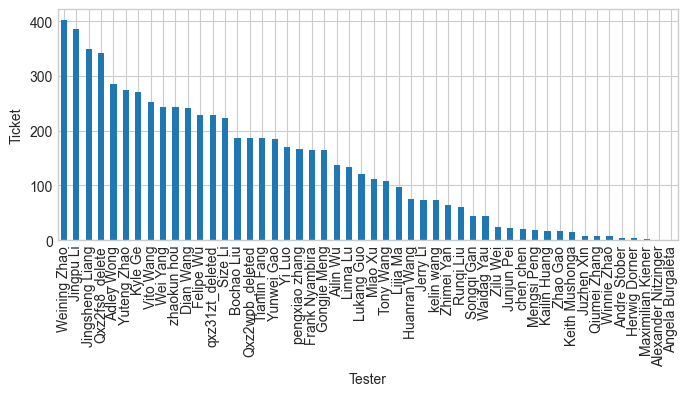

In [3]:
ddf.groupby('author_full_name').id.count().nlargest(50).plot.bar(figsize=(8,3), xlabel='Tester', ylabel='Ticket');

In [5]:
ddf[ddf['assigned_ecu_udf_name']=='HU-MGU_02_A'].groupby('first_use_sop_of_function_udf_name')['id'].count().sort_values(ascending=False)

first_use_sop_of_function_udf_name
24-07                  1325
24-11                   910
25-07                   464
25-03                   366
24-03                   124
No I-Step Relevance       4
23-11                     1
Name: id, dtype: int64

In [6]:
ddf.groupby('aida_businesskey_udf')['id'].count().sort_values(ascending=False)

aida_businesskey_udf
UR-0004794                   674
FE-2102692814                408
FE-2117700614                348
FE-2059895200                250
UR-0004747                   220
                            ... 
FE-2117689012                  1
FE-2117048104                  1
FE-2114873503, UR-0004826      1
FE-2114873503, UR-0004794      1
UR-0005089                     1
Name: id, Length: 603, dtype: int64

In [7]:
ddf.groupby('problem_finder_team_udf_name')['id'].count().sort_values(ascending=False)

problem_finder_team_udf_name
DTSV_China    6691
Name: id, dtype: int64

In [8]:
ddf.groupby('program_name')['id'].count().sort_values(ascending=False)

program_name
IuK        2523
EE_MAIN      31
AF           19
EA            8
EF            3
Name: id, dtype: int64

In [9]:
ddf.groupby('vin_udf')['id'].count().sort_values(ascending=False)

vin_udf
WBA21EH0XPCK79048    580
WBY21CF02PCN18309    469
LBV21FM03SSB30560    415
WBA31HR040HY35514    336
LBV11HS05SSC03583    335
                    ... 
LBV6P0102NM053672      1
LBV21GT06S1A62073      1
LBV21FM03SSB33455      1
LBV11HS05SSC0358       1
WBA41FX030HY22491      1
Name: id, Length: 74, dtype: int64

In [10]:
ddf.groupby('assigned_ecu_udf_name')['id'].count().sort_values(ascending=False)

assigned_ecu_udf_name
HU-MGU_02_A                         3531
HU-MGU_02_L                          926
IDCEVO-25                            848
APPS_Onboard                         290
APP_Mobile_2_0_IOS_CN                175
APP_Mobile_2_0_Android_CN            160
RSE_PADI-01                           95
BT-Device                             92
SP_NavInfo                            62
WAVE-01                               61
BACKEND_ASIA                          55
BACKEND_GLOBAL                        45
SD data_China                         44
BCP-21                                30
SMACC_Devices_CN                      27
Tencent                               22
SF_VehicleProg                        22
APP_Mobile_2_0_HarmonyOS_NEXT_CN      21
BACKEND_ECE_ME                        18
ICON-25                               16
IC_G5-BOX                             15
MARS-01                               14
RAM-01                                14
CDE-01                             

In [11]:
ddf.groupby('problem_severity_udf_name')['id'].count().sort_values(ascending=False)

problem_severity_udf_name
05-unsatisfactory              4265
06-customer irritated          2204
04-deficient                    154
07-customer noticed              60
01-safety relevant                2
03-permanent unsatisfactory       1
Name: id, dtype: int64

In [12]:
ddf.groupby('involved_i_step1_udf_name')['id'].count().sort_values(ascending=False)

involved_i_step1_udf_name
NA06-26-03-380    287
G070-24-11-470    277
G070-25-07-460    256
G070-24-11-450    226
U006-25-07-460    218
                 ... 
NA06-26-03-420      1
NA06-26-03-400      1
NA06-26-03-280      1
NA05-26-03-280      1
U006-26-03-360      1
Name: id, Length: 192, dtype: int64

In [13]:
ddf.groupby('detected_in_release_name')['id'].count().sort_values(ascending=False)

detected_in_release_name
R-24-12    1110
R-24-08     541
R-24-06     535
R-24-09     428
R-24-10     404
R-24-02     393
R-24-04     319
R-24-11     242
R-24-05     165
R-24-07     127
R-24-03      54
R-24-01      53
R-23-08      31
R-23-11      28
R-23-13      22
R-24-13      17
R-20-11       7
R-25-01       3
R-25-06       3
R-23-07       2
R-25-03       1
R-25-04       1
R-18-10       1
R-23-09       1
R-23-03       1
R-22-11       1
R-25-07       1
Name: id, dtype: int64

In [15]:
ddf['creation_time'] = ddf['creation_time'].str.replace('T', ' ').str.replace('Z', '')
ddf['creation_time'] = pd.to_datetime(ddf['creation_time'], format='%Y-%m-%d %H:%M:%S')

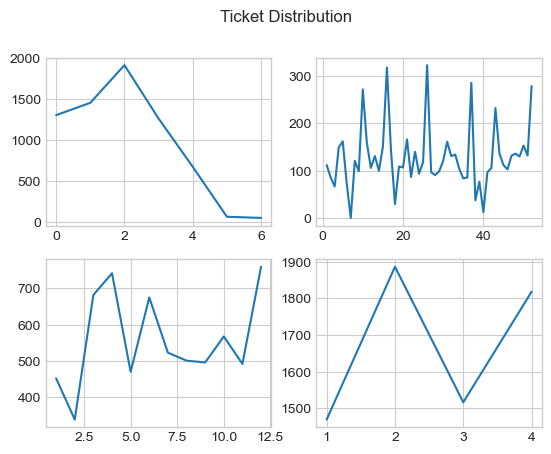

In [16]:
fig, axs = plt.subplots(2, 2)
fig.suptitle('Ticket Distribution')
by_day = ddf.groupby(ddf['creation_time'].dt.dayofweek)['id'].count()
axs[0,0].plot(by_day)
by_week = ddf.groupby(ddf['creation_time'].dt.isocalendar().week)['id'].count()
axs[0,1].plot(by_week)
by_month = ddf.groupby(ddf['creation_time'].dt.month)['id'].count()
axs[1,0].plot(by_month)
by_quarter = ddf.groupby(ddf['creation_time'].dt.quarter)['id'].count()
axs[1,1].plot(by_quarter);

In [16]:
ddf['phase_name'].value_counts()

phase_name
09-Concluded without action    4172
06-Concluded                   2326
04-In Progress                  110
08-In Verification               37
03-In Analysis                   36
01-New                           18
05-In Testing                     1
07-In Pre-Verification            1
Name: count, dtype: int64

In [24]:
"Overall CWA rate is {}, and after excluding the child tickets, the CWA rate is {}".format(
    ddf.query("phase_name=='09-Concluded without action'").shape[0]/ddf.shape[0],
    ddf.query("phase_name=='09-Concluded without action' & parent_child_udf_name!='Child'").shape[0]/ddf.shape[0],
)

'Overall CWA rate is 0.6225936427398896, and after excluding the child tickets, the CWA rate is 0.38755409640352184'